# **ATTENTION E TRANSFORMER**

## **IDEIA INTUITIVA DE ATTENTION (ATENÇÃO)**

Continuando na área de tradução de frases, quando nós, humanos, vamos traduzir uma frase de um idioma para o outro, principalmente se ela for complicada, primeiro lemos a frase inteira para ter uma ideia geral dela. Após issso, começamos a fazer a tradução da frase e, fazendo isso, normalmente revisitamos partes da frase de origem para que a tradução fique boa. Nesse sentido, o idioma de destino pode ter uma ordem de palavras diferente que a ordem do idioma original, como o seguinte da tradução de francês para ingles: "Zone Économique Européenne" = "European Economic Area". Portanto, podemos saltar pela frase de origem para encontrar uma palavra específica quando for a hora de sua tradução aparecer na frase de destino.

Paralelo a isso, pensando em uma rede neural, parece ser aceitável acreditar que uma rede se beneficiaria de poder decidir por si mesma em que parte dos dados de entrada focar em cada passo de tempo.

## **ATTENTION EM REDES SEQ2SEQ**

Um problema observado em redes *seq2seq*, como a do material passado, é a dificuldade em lidar com frases longas. Isso faz sentido, pois imagine um vetor de tamanho fixo (por exemplo 8), que corresponde ao estado interno do *encoder* no último passo de tempo (o contexto), ter que representar uma frase extensa (por exemplo, com 70 palavras). 

Uma mudança no *encoder* para resolver isso é, em vez de descartar os estados internos de todos os passos de tempo e segurar só o último, "guardar" os estados internos de cada passo de tempo. O conjunto desses vetores é conhecido como **estado oculto de origem**. Com isso, teremos o estado interno do *encoder* para a palavra atual e, também, para as outras palavras históricas na frase.

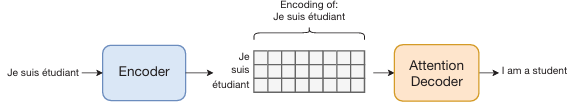 *Como fica essa mudança no encoder*

Para o *decoder*, as alterações são mais complexas. O *decoder* baseado em *attention* faz o seguinte para cada passo de tempo:

1. Calcula um *score* de alinhamento para cada vetor de estado (para cada vetor presente na imagem acima). Esse *score* determina quanta atenção prestar a esse vetor de estado no passo de tempo atual. 
2. Usa uma *softmax* para normalizar esses *scores* para que somem 1. Esse vetor normalizado é conhecido como vetor de alinhamento e consiste na quantidade de vetores de estado que existem, ou seja, como na imagem acima temos 3 vetores de estado, esse vetor de alinhamento teria 3 valores.
3. Multiplica cada vetor de estado por seu *score* de alinhamento. Após isso, soma-se os vetores resultantes elemento a elemento, resultando em um vetor de mesma dimensão que na rede sem atenção.
4. O vetor resultante é usado como entrada para o *decoder* durante esse passo de tempo. Assim como na rede sem atenção, este vetor é concatenado com o *embedding* do passo de tempo anterior para formar a entrada geral para a camada recorrente.


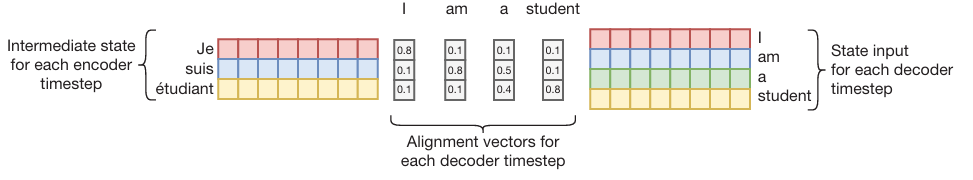 *Exemplificação do que foi explicado acima. No primeiro passo de tempo, ou seja, para a saída 'I', o score de alinhamento é calculado para cada vetor de estado (para cada um dos 3 vetores de entrada) e passa por uma softmax, resultando no vetor de 3 dimensões abaixo de 'I'. Após isso, multiplica-se o vetor de estado de cada passo de tempo (de cada cor) pelo seu score de alinhamento calculado e soma-se esses vetores (elemento a elemento). O vetor resultante, nesse caso o vermelho da direita, é usado como entrada para o decoder.*

Ao analisar os *scores* de alinhamento da imagem acima, nota-se que o *decoder* manterá seu foco em *'je'* durante o primeiro passo de tempo, o que resulta na saída de **'I'**. Isso comprova o uso do mecanismo de atenção, pois a palavra com maior 'foco', ou seja, com maior *score* de pontuação durante o passo de tempo que irá gerar **'I'** é o vetor da palavra *'je'*. A codificação por cores ilustra isso (a primeira entrada do *decoder* é vermelha, assim como a primeira saída do *encoder*). Ele focará principalmente em *'suis'* ao produzir *'am'*. Ao produzir *'a'*, ele foca tanto em *'suis'* quanto em *'étudiant'* (o vetor de entrada é verde, que é uma mistura de azul e amarelo). Finalmente, seu foco está em *'étudiant'* ao produzir *'student'*.